In [ ]:
import pandas_datareader.data as web
import datetime
import pandas as pd

import yfinance as yf

data = yf.download(
    "WMT",
    start="2000-01-01",
    end="2025-01-19",
    auto_adjust=True
)

data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,WMT,WMT,WMT,WMT,WMT
Date,,,,,
2000-01-03,14.154537,14.617970,13.876478,14.485562,25109700
2000-01-04,13.624903,13.942685,13.598420,13.876479,20235300
2000-01-05,13.346840,13.638139,13.174709,13.532213,21056100
2000-01-06,13.492495,13.677866,13.280638,13.346844,19633500
2000-01-07,14.512037,14.604725,13.664620,13.664620,23930700
...,...,...,...,...,...
2025-01-13,90.304161,91.192109,89.879920,90.886263,18617100
2025-01-14,89.574066,90.748131,89.357011,90.629736,13549200


In [ ]:
data.columns = data.columns.droplevel(1)

In [ ]:
data = data.reset_index()

In [ ]:
data

Price,Date,Close,High,Low,Open,Volume
0,2000-01-03,14.154537,14.617970,13.876478,14.485562,25109700
1,2000-01-04,13.624903,13.942685,13.598420,13.876479,20235300
2,2000-01-05,13.346840,13.638139,13.174709,13.532213,21056100
3,2000-01-06,13.492495,13.677866,13.280638,13.346844,19633500
4,2000-01-07,14.512037,14.604725,13.664620,13.664620,23930700
...,...,...,...,...,...,...
6295,2025-01-13,90.304161,91.192109,89.879920,90.886263,18617100
6296,2025-01-14,89.574066,90.748131,89.357011,90.629736,13549200
6297,2025-01-15,90.116699,90.501483,89.593799,89.850319,17348200
6298,2025-01-16,90.077248,90.491621,88.913051,90.274566,13267700


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

sdf = spark.createDataFrame(data)

In [ ]:
sdf

DataFrame[Date: timestamp, Close: double, High: double, Low: double, Open: double, Volume: bigint]

In [ ]:
sdf.count()

6300

In [ ]:
sdf.show(5000)

+-------------------+------------------+------------------+------------------+------------------+---------+
|               Date|             Close|              High|               Low|              Open|   Volume|
+-------------------+------------------+------------------+------------------+------------------+---------+
|2000-01-03 00:00:00|14.154537200927734|14.617970029966608|13.876477988401197|14.485561689305756| 25109700|
|2000-01-04 00:00:00|13.624902725219727|13.942684712979954|13.598420084744989|13.876479324035186| 20235300|
|2000-01-05 00:00:00|13.346839904785156|13.638139173910965| 13.17470884909493|13.532213489401677| 21056100|
|2000-01-06 00:00:00|13.492494583129883|13.677865795903806| 13.28063830498226|13.346843694963917| 19633500|
|2000-01-07 00:00:00| 14.51203727722168|  14.6047252681767|13.664619803024614|13.664619803024614| 23930700|
|2000-01-10 00:00:00|14.247231483459473|14.300194358105607|13.902966737047118|14.247231483459473| 20142900|
|2000-01-11 00:00:00|14.0353

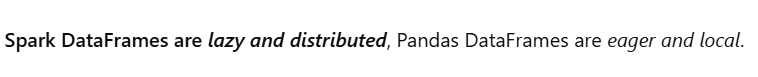

In [ ]:
sdf

DataFrame[Date: timestamp, Close: double, High: double, Low: double, Open: double, Volume: bigint]

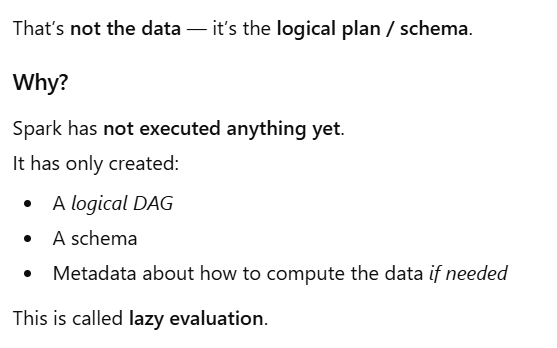

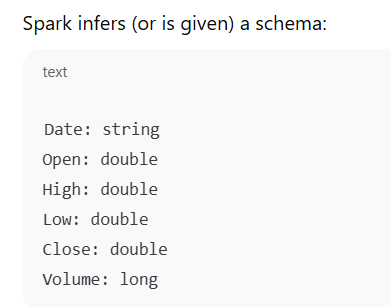

In [ ]:
sdf2 = sdf.filter(sdf.Close > 40)

In [ ]:
sdf2

DataFrame[Date: timestamp, Close: double, High: double, Low: double, Open: double, Volume: bigint]

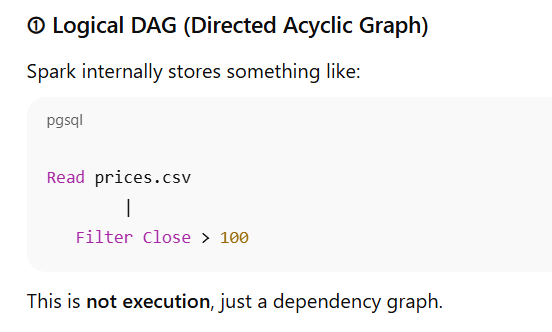

In [ ]:
sdf3 = sdf2.withColumn("day_diff", sdf.Close -sdf.Open)

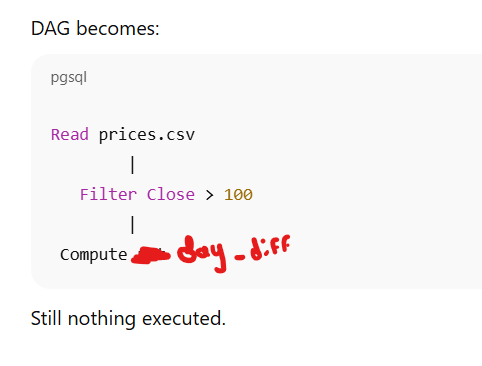

In [ ]:
sdf3.show()

+-------------------+------------------+------------------+------------------+------------------+--------+--------------------+
|               Date|             Close|              High|               Low|              Open|  Volume|            day_diff|
+-------------------+------------------+------------------+------------------+------------------+--------+--------------------+
|2020-04-16 00:00:00| 40.55405807495117|40.734870438898895|39.303694371233085| 39.53354053714673|31882200|  1.0205175378044444|
|2020-04-17 00:00:00| 40.48969268798828| 40.75018448549782|39.757247579666576| 40.29355752246706|30915300|  0.1961351655212198|
|2020-04-22 00:00:00|40.327266693115234| 40.56937036977355| 39.50288457753531|39.839990563204374|19448100| 0.48727612991086033|
|2020-07-10 00:00:00|40.224552154541016|40.436940315480754| 39.17184056354312|39.627400892495594|44236800|   0.597151262045422|
|2020-07-14 00:00:00|40.633941650390625| 40.78476885506612| 39.71666693203381| 39.79362167228513|2645580

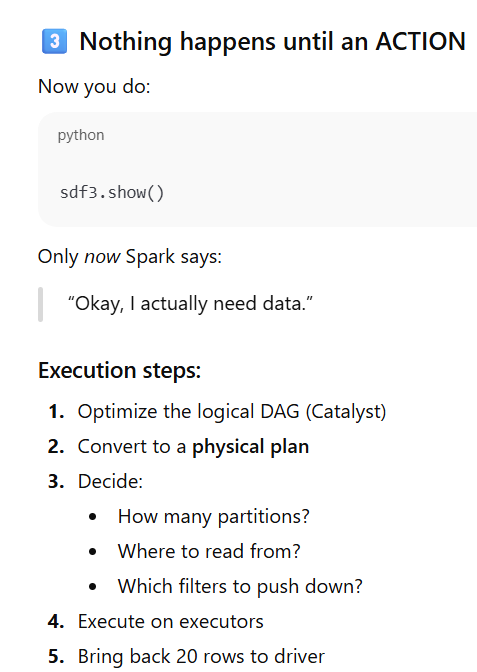

In [ ]:
sdf.columns

['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

In [ ]:
sdf.printSchema()

root
 |-- Date: timestamp (nullable = true)
 |-- Close: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Volume: long (nullable = true)



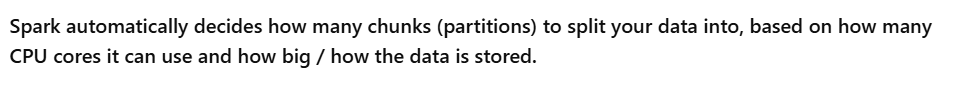

In [ ]:
sdf.rdd.getNumPartitions()

2

In [ ]:
spark.sparkContext.defaultParallelism

2

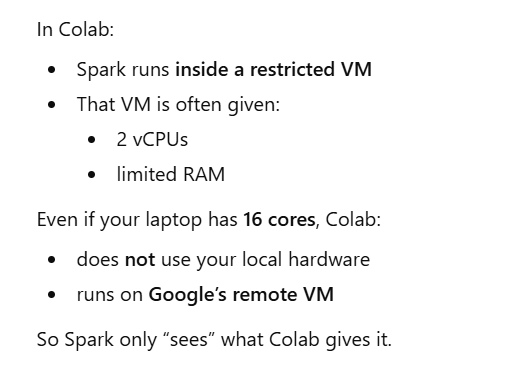

In [ ]:
sdf = sdf.repartition(8)

In [ ]:
sdf.rdd.getNumPartitions()

8

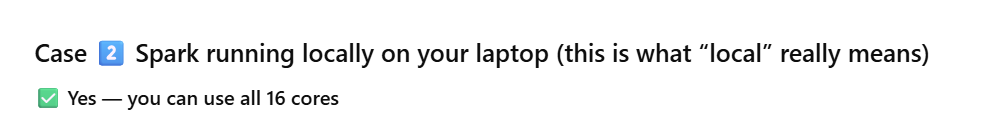

In [ ]:
sdf.show(5)

+-------------------+------------------+------------------+------------------+------------------+--------+
|               Date|             Close|              High|               Low|              Open|  Volume|
+-------------------+------------------+------------------+------------------+------------------+--------+
|2001-12-18 00:00:00|11.925909042358398|11.994327036418458| 11.84894078704692|11.953704425908592|26395500|
|2007-10-17 00:00:00|10.483776092529297| 10.56812021028663| 10.32192609334111|10.517969882930917|71746800|
|2007-11-07 00:00:00|10.014179229736328|10.164630803083432| 9.989103750114465|10.030136412422246|52828800|
|2005-10-21 00:00:00|10.092601776123047|10.176486279897924|10.066112032546554|10.105846963693946|40101900|
|2000-05-04 00:00:00| 10.81817626953125| 11.44128281972371|10.698858148911421| 11.44128281972371|32300700|
+-------------------+------------------+------------------+------------------+------------------+--------+
only showing top 5 rows


In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

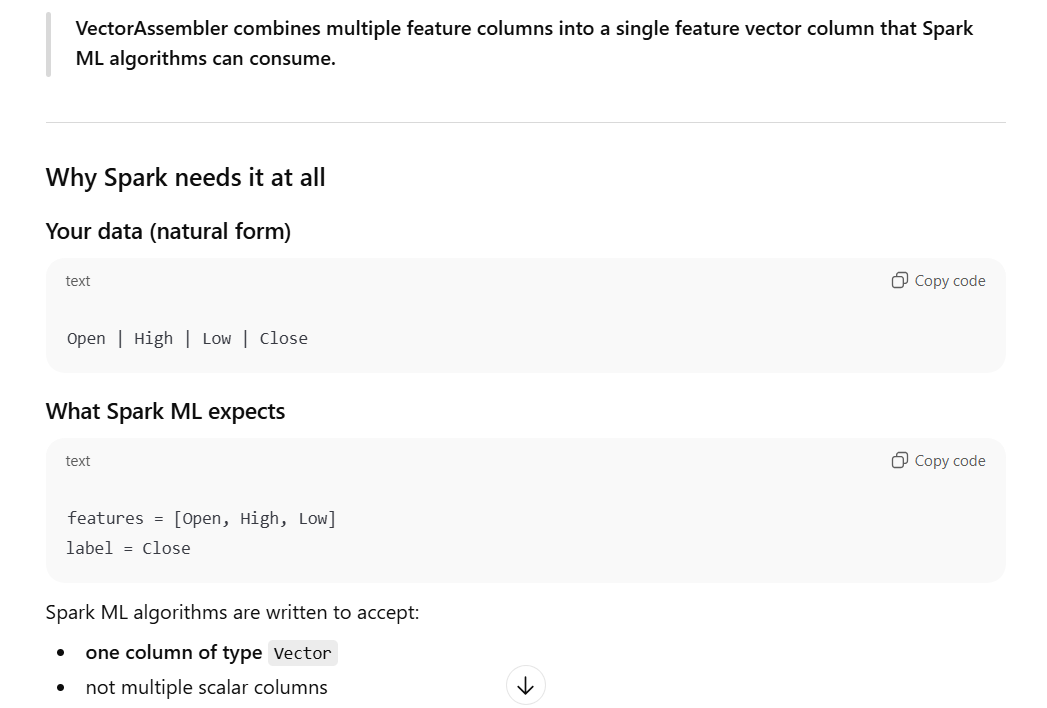

In [ ]:
train_df, test_df = sdf.randomSplit([0.8, 0.2], seed=42)

In [ ]:
train_df.show(5), test_df.show(5)

+-------------------+------------------+------------------+------------------+------------------+--------+
|               Date|             Close|              High|               Low|              Open|  Volume|
+-------------------+------------------+------------------+------------------+------------------+--------+
|2000-01-05 00:00:00|13.346839904785156|13.638139173910965| 13.17470884909493|13.532213489401677|21056100|
|2000-01-07 00:00:00| 14.51203727722168|  14.6047252681767|13.664619803024614|13.664619803024614|23930700|
|2000-01-20 00:00:00|13.426290512084961|13.664627030050967| 13.24091685661659|13.651386920547667|17214300|
|2000-01-31 00:00:00|11.599044799804688|11.757935824459548|11.466636420753849|11.559322043640973|23918100|
|2000-02-09 00:00:00|12.247849464416504|12.737765091642773|12.141923727030866|12.711282445054003|24649800|
+-------------------+------------------+------------------+------------------+------------------+--------+
only showing top 5 rows
+------------

(None, None)

In [ ]:
from pyspark import keyword_only
from pyspark.ml import Transformer

class PipelineDebugger(Transformer):
    @keyword_only
    def __init__(self, message="Debug Stage"):
        super(PipelineDebugger, self).__init__()
        self.message = message

    def _transform(self, dataset):
        print(f"\n==== DEBUG: {self.message} ====")
        dataset.printSchema()
        dataset.show(5, truncate=False)
        return dataset

In [ ]:
assembler = VectorAssembler(
    inputCols=["Open", "High", "Low"],
    outputCol="features"
)

In [ ]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="Close",
    numTrees=100,
    maxDepth=5
)

In [ ]:
# How to use it in your pipeline:
pipeline = Pipeline(stages=[
    assembler,
    PipelineDebugger(message="After VectorAssembler"), # Intercepts and prints
    rf,
    PipelineDebugger(message="After RandomForestRegressor"), # Intercepts and prints
])

In [ ]:
# pipeline = Pipeline(stages=[assembler, rf])

In [ ]:
model = pipeline.fit(train_df)


==== DEBUG: After VectorAssembler ====
root
 |-- Date: timestamp (nullable = true)
 |-- Close: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- features: vector (nullable = true)

+-------------------+------------------+------------------+------------------+------------------+--------+----------------------------------------------------------+
|Date               |Close             |High              |Low               |Open              |Volume  |features                                                  |
+-------------------+------------------+------------------+------------------+------------------+--------+----------------------------------------------------------+
|2000-01-05 00:00:00|13.346839904785156|13.638139173910965|13.17470884909493 |13.532213489401677|21056100|[13.532213489401677,13.638139173910965,13.17470884909493] |
|2000-01-07 00:00:00|14.5120372

In [ ]:
predictions = model.transform(test_df)


==== DEBUG: After VectorAssembler ====
root
 |-- Date: timestamp (nullable = true)
 |-- Close: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- features: vector (nullable = true)

+-------------------+------------------+------------------+------------------+------------------+--------+----------------------------------------------------------+
|Date               |Close             |High              |Low               |Open              |Volume  |features                                                  |
+-------------------+------------------+------------------+------------------+------------------+--------+----------------------------------------------------------+
|2000-01-13 00:00:00|13.797026634216309|14.008882798597776|13.770546432030798|13.982400171929369|15063000|[13.982400171929369,14.008882798597776,13.770546432030798]|
|2000-02-11 00:00:00|11.8771009

In [ ]:
predictions

DataFrame[Date: timestamp, Close: double, High: double, Low: double, Open: double, Volume: bigint, features: vector, prediction: double]

In [ ]:
evaluator = RegressionEvaluator(
    labelCol="Close",
    predictionCol="prediction",
    metricName="r2"
)

r2 = evaluator.evaluate(predictions)
print("r2:", r2)

r2: 0.9866287993287586


In [ ]:
import pandas as pd
import numpy as np
import pyspark.pandas as ps
from pyspark.sql import SparkSession

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [ ]:
spark.conf.set("spark.sql.ansi.enabled", "false")

In [ ]:
df = ps.DataFrame(sdf)

In [ ]:
len(df)

6299

In [ ]:
df #df.show() equivalent

,Open,High,Low,Close,Volume
0,12.1509,12.4655,11.9460,12.2861,1.255525e+08
1,12.0268,12.0268,11.9129,11.9366,4.983329e+07
2,12.3796,12.4352,12.2369,12.2733,6.645470e+07
3,13.6516,13.6965,13.3676,13.6598,3.924462e+07
4,12.6658,12.8325,12.5489,12.6739,1.167533e+08
5,13.4236,13.4291,13.1774,13.3015,4.548188e+07
6,12.5919,12.7247,12.3414,12.4270,2.665842e+07
7,14.1574,14.2564,14.0864,14.1857,7.285349e+07
8,13.1852,13.2781,13.1243,13.1618,3.628287e+07
9,13.7578,14.0567,13.6992,14.0092,3.492673e+07


In [ ]:
df[df['Close']>50]

,Open,High,Low,Close,Volume
385,50.3723,50.9387,50.0040,50.6877,1.537882e+07
387,53.8000,54.2900,53.4733,54.2800,1.636960e+07
398,75.3000,75.5800,74.5900,75.2400,1.483199e+07
400,53.6110,53.7410,53.2090,53.3917,1.178952e+07
418,74.1200,74.4400,72.7800,73.1800,4.956750e+07
429,60.6200,61.3450,60.2900,60.4100,1.926052e+07
430,80.0500,81.1150,79.8500,80.9400,1.159139e+07
435,61.3200,61.5260,60.8500,60.8700,1.402944e+07
448,52.6877,52.8007,50.3630,51.9437,4.277445e+07
449,82.6800,83.7700,82.5100,83.6800,1.061249e+07


In [ ]:
df.groupby('Close').mean()

,Open,High,Low,Volume
Close,,,,
10.9710,10.980100,11.052250,10.922150,7.601606e+07
14.9410,14.831850,15.023350,14.786250,2.302907e+07
19.7974,19.869400,19.960500,19.759900,1.964415e+07
43.9387,43.444300,44.079000,43.329700,1.717474e+07
14.7820,14.917500,14.974800,14.736400,4.255829e+07
28.8156,28.699700,28.911000,28.324900,2.372278e+07
71.0300,70.180000,71.100000,69.950000,1.353379e+07
14.3798,14.504900,14.615600,14.259150,1.414740e+07
12.4580,12.364900,12.548900,12.328100,5.935421e+07
